## NetCDF data

In [17]:
%matplotlib inline

import os
import glob
import xarray as xr
import rioxarray
# import cartopy.crs as ccrs
import pyproj
import numpy as np
import scipy
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator, FormatStrFormatter, AutoMinorLocator
from matplotlib.colors import BoundaryNorm, LogNorm
from matplotlib.patches import Rectangle
import sys
import cmaps
# sys.path.insert(1, '../Tools/')
#from dea_tools.datahandling import paths_to_datetimeindex
#from dea_tools.plotting import rgb

plt.style.use('latex_default.mplstyle')

"""Constants"""
# omega = 7.292*10**(-5)
g = 9.80665
Rd = 287.06
cp = 3.5 * Rd
Re = 6371229 # m (Radius of Earth for GRIB2 format - applies to ERA5 on ML)
p0 = 101325

cap=Rd/cp
capi=1/cap
capp=1.-cap # Cv/Cp
cappi=1./capp # Cp/Cv
wexnr=Rd/(cp-Rd) # Rd/Cv
compri=Rd/p0**cap
# th00=tt00*(pr00/pref00)**(-cap)
# rh00=pr00/(rg*tt00)

def tf(zeta):
    return zeta*zeta*zeta*(10.-15.*zeta+6.*zeta*zeta)
def tfd(zeta):
    return 30.*zeta*zeta*(1.-2.*zeta+zeta*zeta)

In [18]:
geotiff_path = "../data/dems/cop90m_sa.tif"
# geotiff_path = "data/cop90_sa_test.tif"
geotiff_da   = rioxarray.open_rasterio(geotiff_path)
ds = geotiff_da.to_dataset('band')
ds = ds.rename({1: 'height', 'x': "lon", 'y': "lat"})

"""Transform WGS84 (lat,lon) to some projection"""
# - Select projection - #
# projection = "Mercator (cylindrical)"
# projection = "SAD 1969 Lambert South America"
# projection = "SAD 1969 Albers South America"
projection = "Projection: Lambert conformal conic"
# projection = "Projection: Albers conic"

if projection == "Projection: Lambert conformal conic":
    proj4_str = "+proj=lcc +lat_0=-51 +lon_0=-71 +lat_1=-49 +lat_2=-53 +x_0=0 +y_0=0 +ellps=aust_SA +units=m +no_defs +type=crs"
elif projection == "Projection: Albers conic":
    proj4_str = "+proj=aea +lat_0=-51 +lon_0=-71 +lat_1=-49 +lat_2=-53 +x_0=0 +y_0=0 +ellps=aust_SA +units=m +no_defs +type=crs"
if projection == "SAD 1969 Lambert South America":
    proj4_str = "+proj=lcc +lat_0=-32 +lon_0=-60 +lat_1=-5 +lat_2=-42 +x_0=0 +y_0=0 +ellps=aust_SA +units=m +no_defs +type=crs"
elif projection == "SAD 1969 Albers South America":
    proj4_str = "+proj=aea +lat_0=-32 +lon_0=-60 +lat_1=-5 +lat_2=-42 +x_0=0 +y_0=0 +ellps=aust_SA +units=m +no_defs +type=crs"
elif projection == "Mercator (cylindrical)":
    proj4_str = "+proj=merc" ## Mercator projection (cylindrical)

proj_object = pyproj.Proj(proj4_str)
## GeographicCRS is ordered lon,lat ### EPSG:4326 is ordered lat,lon
# index 0: lon
# index 1: lat

"""Region"""
region = "patagonia"
region = "fitzroy"
# region = "darwin"

"""Select resolution and number of grid points"""
# fname_topo = "pata_amtm_0800m_0384_temp.nc"
# dx = 800
# nx = 384
# ny = nx

if region == "darwin":
    fname_topo = f"{region}_1600m_0512_temp.nc"
    dx = 1600
    nx = 512

    # fname_topo = f"{region}_0800m_1024_temp.nc"
    # dx = 800
    # # nx = 768
    # nx = 1024
    
    # fname_topo = f"{region}_0400m_2048_temp.nc"
    # dx = 400
    # nx = 2048

    ny = int(3/4 * nx)
else:   
    # fname_topo = f"{region}_0800m_2048_temp.nc"
    # dx = 800
    # nx = 2048

    fname_topo = f"{region}_1600m_1024_temp.nc"
    dx = 1600
    nx = 1024
    
    ny = nx

print(f"DEM for region: {region}")
print(f"dx:: {dx}")
print(f"nx: {nx}")

lon_mesh, lat_mesh = np.meshgrid(ds.lon, ds.lat, indexing='xy')
(xmesh,ymesh) = proj_object(lon_mesh, lat_mesh)
ds = ds.assign_coords({"xmesh": (["lat","lon"],xmesh), "ymesh": (["lat","lon"],ymesh)})

"""Generate equidistant grid (based on mesh and pad for final domain)"""
xcenter = (ds.xmesh.max().values + ds.xmesh.min().values) / 2
ycenter = (ds.ymesh.max().values + ds.ymesh.min().values) / 2
# if projection == "Projection: Lambert conformal conic":
if region == "darwin":
    # xcenter = xcenter - 0 * 1000
    ycenter = ycenter - 480 * 1000
else:
    ycenter = ycenter - 160 * 1000 # try to match Fitz Roy in center of domain
    # ycenter = ycenter - 210 * 1000
xrange = dx * nx
yrange = dx * ny
xx = np.arange(int(xcenter/dx)*dx - xrange/2, int(xcenter/dx)*dx + xrange/2, dx)
yy = np.arange(int(ycenter/dx)*dx - yrange/2, int(ycenter/dx)*dx + yrange/2, dx)
xsim = np.arange(-xrange/2, xrange/2, dx) / 1000 # use for visualization
ysim = np.arange(-yrange/2, yrange/2, dx) / 1000
print("left bound: ", xsim[0], "right bound: ", xsim[-1])
print("nx:", len(xx), "ny:", len(yy))
print("dx:", xx[1]-xx[0], "dy:", yy[1]-yy[0])

xgrid, ygrid = np.meshgrid(xx, yy, indexing='xy')
(lon_grid, lat_grid) = proj_object(xgrid, ygrid, inverse=True)

ds

DEM for region: fitzroy
dx:: 1600
nx: 1024
left bound:  -819.2 right bound:  817.6
nx: 1024 ny: 1024
dx: 1600.0 dy: 1600.0


<xarray.Dataset> Size: 4GB
Dimensions:      (lat: 14850, lon: 14271)
Coordinates:
  * lon          (lon) float64 114kB -75.71 -75.71 -75.71 ... -63.82 -63.82
  * lat          (lat) float64 119kB -43.52 -43.52 -43.52 ... -55.89 -55.89
    spatial_ref  int64 8B 0
    xmesh        (lat, lon) float64 2GB -3.833e+05 -3.832e+05 ... 4.502e+05
    ymesh        (lat, lon) float64 2GB 8.215e+05 8.215e+05 ... -5.666e+05
Data variables:
    height       (lat, lon) float32 848MB ...
Attributes:
    AREA_OR_POINT:  Area
    scale_factor:   1.0
    add_offset:     0.0

In [19]:
"""Interpolate from mesh to grid"""
# - Reshape/Flatten old and new coordinates into 1D arrays - #
xmesh_1d = ds.xmesh.values.flatten()
ymesh_1d = ds.ymesh.values.flatten()
zmesh_1d = ds.height.values.flatten()

xgrid_1d = xgrid.flatten()
ygrid_1d = ygrid.flatten()

# - Perform bilinear interpolation - #
zgrid_1d = scipy.interpolate.griddata((xmesh_1d, ymesh_1d), zmesh_1d, (xgrid_1d, ygrid_1d), method='nearest')

# - Reshape interpolated values back to 2D grid - #
zgrid = zgrid_1d.reshape(xgrid.shape)
ds['z'] = xr.DataArray(zgrid, coords={"y": yy/1000, "x": xx/1000}) # switch to kilometer
ds = ds.assign_coords({"lon_grid": (["y","x"],lon_grid), "lat_grid": (["y","x"],lat_grid)})

ds

<xarray.Dataset> Size: 4GB
Dimensions:      (lat: 14850, lon: 14271, y: 1024, x: 1024)
Coordinates:
  * lon          (lon) float64 114kB -75.71 -75.71 -75.71 ... -63.82 -63.82
  * lat          (lat) float64 119kB -43.52 -43.52 -43.52 ... -55.89 -55.89
    spatial_ref  int64 8B 0
    xmesh        (lat, lon) float64 2GB -3.833e+05 -3.832e+05 ... 4.502e+05
    ymesh        (lat, lon) float64 2GB 8.215e+05 8.215e+05 ... -5.666e+05
  * y            (y) float64 8kB -844.8 -843.2 -841.6 ... 788.8 790.4 792.0
  * x            (x) float64 8kB -720.0 -718.4 -716.8 ... 913.6 915.2 916.8
    lon_grid     (y, x) float64 8MB -83.16 -83.13 -83.1 ... -59.79 -59.77 -59.76
    lat_grid     (y, x) float64 8MB -58.04 -58.04 -58.05 ... -43.27 -43.26
Data variables:
    height       (lat, lon) float32 848MB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    z            (y, x) float64 8MB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0 0.0
Attributes:
    AREA_OR_POINT:  Area
    scale_factor:   1.0
    add_offset:     0.0

In [20]:
def calc_fft_1d(data, resolution):
    """
    Calculate the power spectrum of a 1D array (e.g., topography along one line).

    Parameters:
        data (np.ndarray): 1D array of topography values.
        resolution (float): Spatial resolution of the data (distance between adjacent points).

    Returns:
        freqs (np.ndarray): Array of spatial frequencies (1/wavelength).
        psd (np.ndarray): Power spectral density (PSD) values.
    """
    non_zero_indices = np.nonzero(data)[0]
    start, end = non_zero_indices[0], non_zero_indices[-1]
    data = data[start:end + 1]

    # Remove the mean to avoid large DC component
    data_demeaned = data - np.mean(data)
    
    ## Mirror data
    data_mirrored = np.concatenate([data_demeaned, data_demeaned[::-1]])
    data_repeated = np.tile(data_mirrored, 2)

    # Apply a window function (Hann window) / Welch
    #window = np.hanning(len(data))
    #data_windowed = data_demeaned * window

    # Compute the FFT
    data = data_repeated
    fft_result = np.fft.rfft(data)

    # Compute the power spectral density (PSD)
    # psd = (np.abs(fft_result) ** 2) / (len(data)*resolution)
    psd = (np.abs(fft_result) ** 2) * (2 / (len(data)**2 * resolution))  # unit: m³
    # psd = (np.abs(fft_result) ** 2) / len(data) * (1/resolution)
    # psd = (np.abs(fft_result) ** 2) / (len(data))
    # psd = (np.abs(fft_result) ** 2) / resolution

    # Normalize by the window function's energy correction factor
    #correction_factor = np.sum(window ** 2) / len(window)
    #psd /= correction_factor

    # Compute the spatial frequencies
    freqs = np.fft.rfftfreq(len(data), d=resolution)

    # Convert frequencies to wavelengths
    wavelengths = np.zeros_like(freqs)
    nonzero_freqs = freqs != 0
    wavelengths[nonzero_freqs] = 1 / np.abs(freqs[nonzero_freqs])
    wavelengths[~nonzero_freqs] = np.inf  # Handle the zero-frequency term

    # PSD is unit m^3
    # psd = psd * freqs**2 * 1000
    # I want unit m^2/km (Multiply power spectra with frequencies)
    # print(f"Wavelengths for FFT range: {wavelengths[2] / 1000}, {wavelengths[-1] / 1000}")
    
    return psd, wavelengths / 1000

Cutoff: 3200m, Sigma: 0.8493218002880191
Projection coordinates:
x_fitz: -148.47372544152375km
y_fitz: 183.61429446962887km
EULAG coordinates:
x_fitz: -246.4000000000035km (x_offset: 98.39999999999998km)
y_fitz: 209.60000000000298km (y_offset: -26.399999999999977km)
Projection coordinates:
x_coral: 214.44601431055722km
y_coral: -310.66527087874226km
EULAG coordinates:
x_coral: 116.80000000000166km (x_offset: 98.39999999999998km)
y_coral: -284.80000000000405km (y_offset: -26.399999999999977km)
Maximum altitude: 2901.0475519635684m at (-176.0km, 184.0km)


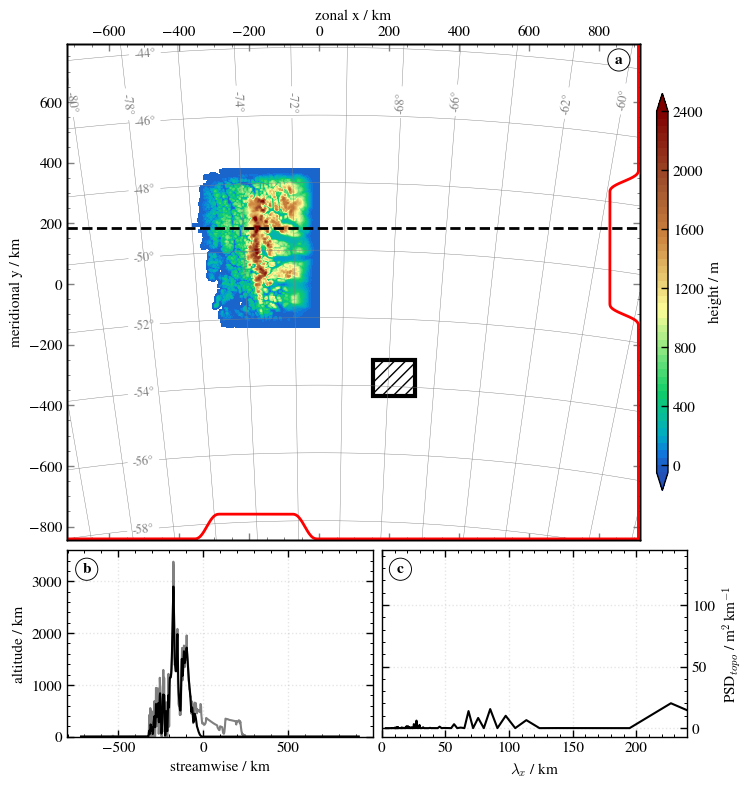

In [23]:
## projection == "Projection: Lambert conformal conic" or projection == "Projection: Albers conic"
xcut = [-320,440]
ycut = [-460,340]
wtrans = 40 # km

# fitz = [-73.043266,-49.271455] # original
fitz = [-73.043266,-49.33] # tuned to maximum altitude

igrid = 2
nlab = 8
lab_lon = -500
lab_lat = 600

if region == "darwin":
    xcut = [-172,360]
    ycut = [-520,-176]
    wtrans = 20 # km

    fitz = [-69.598383, -54.662107] # This is Mtn Darwin!

    igrid = 1
    lab_lon = -100
    lab_lat = -200

elif region == "fitzroy":
    xcut = [-320,-40]
    ycut = [-100,340]


coral = [-67.75,-53.75]

cmap_terrain = cmaps.get_terrain_cmap()

"""TERRRAIN MODULATION WITH 5TH ORDER POLYNOM"""
xln  = ds.x.values
yln  = ds.y.values

wtrans = int(wtrans / (xln[1]-xln[0]))
transition = tf(np.linspace(0, 1, 2*wtrans))

xcut = [np.abs(xln - v).argmin() for v in xcut]
ycut = [np.abs(yln - v).argmin() for v in ycut]
# xcut = [np.where(xln == xcut[0])[0][0], np.where(xln == xcut[1])[0][0]]
# ycut = [np.where(yln == ycut[0])[0][0], np.where(yln == ycut[1])[0][0]]

terrain_mod_x = np.ones(len(xln))
terrain_mod_x[:xcut[0]-wtrans] = 0
terrain_mod_x[xcut[0]-wtrans:xcut[0]+wtrans] = transition
terrain_mod_x[xcut[1]-wtrans:xcut[1]+wtrans] = 1-transition
terrain_mod_x[xcut[1]+wtrans:] = 0

terrain_mod_y = np.ones(len(yln))
terrain_mod_y[:ycut[0]-wtrans] = 0
terrain_mod_y[ycut[0]-wtrans:ycut[0]+wtrans] = transition
terrain_mod_y[ycut[1]-wtrans:ycut[1]+wtrans] = 1-transition
terrain_mod_y[ycut[1]+wtrans:] = 0

ds["z_mod"] = ds["z"] * np.expand_dims(terrain_mod_y, axis=1)
ds["z_mod"] = ds["z_mod"] * np.expand_dims(terrain_mod_x, axis=0)

"""Smooth terrain so it is differentiable (2*dx)"""
ds["z_smoothed"] = ds["z_mod"]
# - Smooth the field using a Gaussian filter - #
sigma_gauss = 1 # higher -> more smoothing
# sigma_gauss = 2  # higher -> more smoothing

cutoff = 2*dx # m
sigma = cutoff / (2 * np.sqrt(2 * np.log(2)) * dx)
print(f"Cutoff: {cutoff}m, Sigma: {sigma}")
ds["z_smoothed"].values = scipy.ndimage.gaussian_filter(ds["z_mod"].values, sigma)


"""Plot in different projections"""
## projection == "Projection: Lambert conformal conic" or projection == "Projection: Albers conic":
x_cross = -140

# fig, ax = plt.subplots(1,1, figsize=(6,6), subplot_kw={'projection': ccrs.LambertConformal()})
spacing = 0.03
fig, axes = plt.subplots(2,2, figsize=(8,9), gridspec_kw={"wspace": spacing, "hspace": spacing, "width_ratios":[15,1], "height_ratios":[8,3]})
ax  = axes[0,0]
ax2 = axes[1,0]

axt1 = ax.twinx()
axt2 = ax.twiny()

# ax.set_aspect("equal", adjustable='datalim') # adjustable='datalim'
axes[0,1].axis("off")
axes[1,1].axis("off")

axes[1,0].remove()
axes[1,1].remove()
gs2 = fig.add_gridspec(2,2, hspace=spacing, wspace=spacing, height_ratios=[8,3], width_ratios=[1,1])
ax2 = fig.add_subplot(gs2[1,0])
ax3 = fig.add_subplot(gs2[1,1])

"""Twin axes for terrain modulations"""
axt1.plot(xln, terrain_mod_x, color="red", lw=2)
axt1.set_ylim(-0.05,20)
axt2.plot(terrain_mod_y, yln, color="red", lw=2)
axt2.set_xlim(20,-0.05)
axt1.tick_params(which="both", bottom=False, top=False, labelbottom=False, labeltop=False, left=False, right=False, labelleft=False, labelright=False)
axt2.tick_params(which="both", bottom=False, top=False, labelbottom=False, labeltop=False, left=False, right=False, labelleft=False, labelright=False)

"""Main axis with terrain and contours for lat/lon"""
zlevels = np.arange(-50,2450,50)
zlevels_lab = np.arange(0,2800,400)
lon_levels = np.arange(-90,-50,igrid)
lat_levels = np.arange(-60,-40,igrid)

lw1 = 0.3
cgrid = "grey"
# contf_topo = ax.contourf(xsim, ysim, ds.z_smoothed, levels=zlevels, cmap="turbo", extend='both')
# cont_lon   = ax.contour(xsim, ysim, ds.lon_grid, levels=lon_levels, colors='white', linestyles="-", linewidths=lw1)
# cont_lat   = ax.contour(xsim, ysim, ds.lat_grid, levels=lat_levels, colors='white', linestyles="-", linewidths=lw1)

zsmooth = ds.z_smoothed.values
contf_topo = ax.contourf(ds.x, ds.y, np.where(zsmooth == 0, np.nan, zsmooth), levels=zlevels, cmap=cmap_terrain, extend='both')
## contf_topo = ax.contourf(ds.x, ds.y, ds.z_mod, levels=zlevels, cmap="turbo", extend='both')
## contf_topo = ax.contourf(ds.x, ds.y, ds.z, levels=zlevels, cmap="turbo", extend='both')
cont_lon   = ax.contour(ds.x, ds.y, ds.lon_grid, levels=lon_levels, colors=cgrid, linestyles="-", linewidths=lw1)
cont_lat   = ax.contour(ds.x, ds.y, ds.lat_grid, levels=lat_levels, colors=cgrid, linestyles="-", linewidths=lw1)
lat_pos = np.linspace(ds.y.min().values,ds.y.max().values,nlab)
lon_pos = np.linspace(ds.x.min().values,ds.x.max().values,nlab)
label_lon = []
label_lat = []
for lab in lat_pos:
    label_lat.append((lab_lon,lab))
for lab in lon_pos:
    label_lon.append((lab,lab_lat))
ax.clabel(cont_lon, inline=True, fontsize=9, colors=cgrid,fmt="%1.0f°", manual=label_lon)
ax.clabel(cont_lat, inline=True, fontsize=9, colors=cgrid,fmt="%1.0f°", manual=label_lat)

"""Wind barbs"""
# res = 50
# barbs = ax.barbs(ds.x[::res], ds.y[::res], U[::res,::res], V[::res,::res], length=5, lw=0.5, color = "red")

"""Lidar locations"""
ds.attrs['dx'] = (ds.x[1]-ds.x[0]).values
ds.attrs['nx'] = len(ds.x)
ds.attrs['xoff'] = (ds.x[0]+ds.x[-1]).values / 2
ds.attrs['yoff'] = (ds.y[0]+ds.y[-1]).values / 2

## Mountain and Coral location
(x_fitz, y_fitz) = pyproj.Proj(proj4_str)(fitz[0], fitz[1])
x_fitz = x_fitz / 1000
y_fitz = y_fitz / 1000
print("Projection coordinates:")
print(f"x_fitz: {x_fitz}km")
print(f"y_fitz: {(y_fitz)}km")
print("EULAG coordinates:")
print(f"x_fitz: {round((x_fitz-ds.xoff)/ds.dx)*ds.dx}km (x_offset: {ds.xoff}km)")
print(f"y_fitz: {round((y_fitz-ds.yoff)/ds.dx)*ds.dx}km (y_offset: {ds.yoff}km)")

# CORAL
(x_coral, y_coral) = pyproj.Proj(proj4_str)(coral[0], coral[1])
x_coral = x_coral / 1000
y_coral = y_coral / 1000
print("Projection coordinates:")
print(f"x_coral: {x_coral}km")
print(f"y_coral: {(y_coral)}km")
print("EULAG coordinates:")
print(f"x_coral: {round((x_coral-ds.xoff)/ds.dx)*ds.dx}km (x_offset: {ds.xoff}km)")
print(f"y_coral: {round((y_coral-ds.yoff)/ds.dx)*ds.dx}km (y_offset: {ds.yoff}km)")

ax.hlines(y_fitz, xmin=ds.x.min(),xmax=ds.x.max(), color="black", lw=2, ls="--")
# ax.hlines(y_coral, xmin=ds.x.min(),xmax=ds.x.max(), color="deeppink", lw=2, ls="--")

# xoff = 100000
# yoff =  52000
# print(f"i_coral: {int((x_coral-xoff)/dx) + nx/2}, j_coral: {int((y_coral-yoff)/dx) + ny/2}")
# print(f"i_fitz: {int((x_cross*1000-xoff)/dx) + nx/2}, j_fitz: {int((y_cross*1000-yoff)/dx) + ny/2}")


"""AMTM / CORAL measurement location (add AMTM plot)"""
w_amtm = 120
x_amtm = x_coral - w_amtm / 2
y_amtm = y_coral - w_amtm / 2
rect = Rectangle((x_amtm, y_amtm), w_amtm, w_amtm, linewidth=3, edgecolor='black', facecolor='none', hatch='///') # stripe patternfill=True)
ax.add_patch(rect)
# ax.annotate('CORAL', xy=(x_coral, y_coral), xytext=(x_coral+30, y_coral+30), weight="bold",
#             arrowprops=dict(edgecolor="white", facecolor='white', shrink=0.05), bbox={"boxstyle" : "round", "lw":0.67, "facecolor":"white", "edgecolor":"black"})

ymax, xmax = np.unravel_index(np.argmax(zsmooth), zsmooth.shape)
print(f"Maximum altitude: {np.max(zsmooth)}m at ({ds.x[xmax].values}km, {ds.y[ymax].values}km)")

"""Streamwise cross section"""
yslices = np.arange(100,200,4)
# for y in yslices:
#     ax2.plot(ds.x, ds["z_smoothed"].sel(y=y, method="nearest"), lw=0.2, color="black")
# ax2.plot(ds.x, ds["z_smoothed"].sel(y=y_coral, method="nearest"), lw=1.5, color="deeppink")
ax2.plot(ds.x, ds["z"].sel(y=y_fitz, method="nearest"), lw=1.5, color="grey")
ax2.plot(ds.x, ds["z_smoothed"].sel(y=y_fitz, method="nearest"), lw=1.5, color="black")
ax2.set_xlabel("streamwise / km")
ax2.set_ylabel("altitude / km")
# ax2.set_xlim([-500,500])
ax2.set_ylim([0,3600])
# ax2.set_yticks([0,500,1000,1500,2000,2500,3000,3500])
# ax2.set_xticks([-750,-500,-250,0,250,500,750,1000])
# ax2.set_yticks([0,1000,2000,3000])
ax2.tick_params(which='both', top=True, right= True, bottom=True, left=True, labelbottom=True)
ax2.grid()

"""Topo spectra"""
# for y in yslices:
#     topo = ds["z"].sel(y=y, method="nearest").values
#     psd_topo, wavelength_topo = fft_topo(topo)

#     ax3.plot(wavelengths,psd,lw=0.2,color="red")
psd_topo, wavelength_topo = calc_fft_1d(ds["z_smoothed"].sel(y=y_fitz, method="nearest").values, dx)
ax3.plot(wavelength_topo,psd_topo,lw=1.5,color="black")
ax3.set_xlim([0,240])
# ax3.set_ylim([0,500])
ax3.set_xlabel("$\lambda_x$ / km")
ax3.set_ylabel(r"PSD$_{topo}$ / m$^2\,$km$^{-1}$")
ax3.yaxis.set_label_position("right")
ax3.tick_params(which='both', bottom=True, top=True, labelbottom=True, labelleft=False, labelright=True)
ax3.grid()

"""Grid"""
# ax.hlines(ds.y.values,xmin=ds.x[0], xmax=ds.x[-1], lw=0.1, color='black')
# ax.vlines(ds.x.values,ymin=ds.y[0], ymax=ds.y[-1], lw=0.1, color='black')
# ax.scatter(xgrid_1d,ygrid_1d, color="black", s=1, marker=".")
# ax.scatter(xgrid_1d,ygrid_1d, color="grey", s=1/3000) # Coral location

"""Env rectangle"""
# rect1=plt.Rectangle(xy=(-800,-100), width=400, height=400, edgecolor='white', 
#                     fill=False, linewidth=2, linestyle='dotted')
# ax.add_patch(rect1)

"""Formatting"""
ypp = 0.88
ax.text(0.97, 0.96, "a", transform=ax.transAxes, horizontalalignment="right", weight='bold', bbox={"boxstyle" : "circle", "lw":0.67, "facecolor":"white", "edgecolor":"black"})
ax2.text(0.05, ypp, "b", transform=ax2.transAxes, weight='bold', bbox={"boxstyle" : "circle", "lw":0.67, "facecolor":"white", "edgecolor":"black"})
ax3.text(0.05, ypp, "c", transform=ax3.transAxes, weight='bold', bbox={"boxstyle" : "circle", "lw":0.67, "facecolor":"white", "edgecolor":"black"})
# ax.text(0.985,0.98, projection, horizontalalignment='right', verticalalignment='top', transform=ax.transAxes, weight='bold', bbox={"boxstyle" : "round", "lw":0.67, "facecolor":"white", "edgecolor":"black"})

ax.xaxis.set_label_position('top')
ax.xaxis.set_minor_locator(AutoMinorLocator())
ax.yaxis.set_minor_locator(AutoMinorLocator())
ax2.xaxis.set_minor_locator(AutoMinorLocator())
ax2.yaxis.set_minor_locator(AutoMinorLocator())
ax3.xaxis.set_minor_locator(AutoMinorLocator())
ax3.yaxis.set_minor_locator(AutoMinorLocator())
ax.tick_params(which='both', top=True, right= True, bottom=True, left=True, labelbottom=False,labeltop=True, color="grey")
#axt1.spines['bottom'].set_color('grey')
#axt1.spines['top'].set_color('grey') 
#axt2.spines['right'].set_color('grey')
#axt2.spines['left'].set_color('grey')
ax.set_xlabel("zonal x / km")
ax.set_ylabel("meridional y / km")
cbar = fig.colorbar(contf_topo, ax=axes[0,1], location='right', ticks=zlevels_lab, shrink=0.8, fraction=0.8, aspect=35) # , fraction=1, aspect=30
cbar.set_label("height / m")

"""Save figure"""
folder   = "../data/darwin_180521"
fig_name = f"{region}_topo_temp.png"
fig.savefig(os.path.join(folder,fig_name), facecolor='w', edgecolor='w', format='png', dpi=300, bbox_inches='tight') # orientation='portrait'

In [24]:
"""Save NETCDF for PMAP"""
ds_pmap = ds["z_smoothed"]
ds_pmap = ds_pmap.drop_vars(["spatial_ref","lon_grid","lat_grid"])
ds_pmap = ds_pmap.transpose('x', 'y')
ds_pmap.to_netcdf(os.path.join("../data/pmap-topos", fname_topo)) # format='NETCDF3_64BIT', engine='h5netcdf'
ds_pmap

<xarray.DataArray 'z_smoothed' (x: 1024, y: 1024)> Size: 8MB
array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])
Coordinates:
  * y        (y) float64 8kB -844.8 -843.2 -841.6 -840.0 ... 788.8 790.4 792.0
  * x        (x) float64 8kB -720.0 -718.4 -716.8 -715.2 ... 913.6 915.2 916.8

In [10]:
"""Save NETCDF for EULAG"""
ds_eulag = ds["z_smoothed"]
ds_eulag = ds_eulag.drop_vars(["spatial_ref","lon_grid","lat_grid"])
ds_eulag.to_netcdf(os.path.join("../data/eulag-topos", fname_topo), format='NETCDF3_64BIT') # format='NETCDF3_64BIT', engine='h5netcdf'
ds["z_smoothed"].max()

<xarray.DataArray 'z_smoothed' ()> Size: 8B
array(2110.3386838)
Coordinates:
    spatial_ref  int64 8B 0

In [9]:
ds_test = xr.open_dataset(os.path.join("./data/eulag-topos", fname_topo))
ds_test["z_smoothed"]

<xarray.DataArray 'z_smoothed' (y: 1536, x: 2048)> Size: 25MB
[3145728 values with dtype=float64]
Coordinates:
  * y        (y) float64 12kB -653.6 -653.2 -652.8 -652.4 ... -40.4 -40.0 -39.6
  * x        (x) float64 16kB -309.2 -308.8 -308.4 -308.0 ... 508.8 509.2 509.6

In [ ]:
###### SAD 1969 Lambert South America #####
# proj_cs = PROJCS["South_America_Lambert_Conformal_Conic",
#     GEOGCS["SAD69",
#         DATUM["South_American_Datum_1969",
#             SPHEROID["GRS 1967 Modified",6378160,298.25,
#                 AUTHORITY["EPSG","7050"]],
#             AUTHORITY["EPSG","6618"]],
#         PRIMEM["Greenwich",0,
#             AUTHORITY["EPSG","8901"]],
#         UNIT["degree",0.0174532925199433,
#             AUTHORITY["EPSG","9122"]],
#         AUTHORITY["EPSG","4618"]],
#     PROJECTION["Lambert_Conformal_Conic_2SP"],
#     PARAMETER["latitude_of_origin",-32],
#     PARAMETER["central_meridian",-60],
#     PARAMETER["standard_parallel_1",-5],
#     PARAMETER["standard_parallel_2",-42],
#     PARAMETER["false_easting",0],
#     PARAMETER["false_northing",0],
#     UNIT["metre",1,
#         AUTHORITY["EPSG","9001"]],
#     AXIS["Easting",EAST],
#     AXIS["Northing",NORTH],
#     AUTHORITY["ESRI","102015"]]